# 02 — Modeling

Two regression models from the ITCS 3156 syllabus, trained on the same preprocessed feature matrix:

1. **Ridge Regression** with GridSearchCV over alpha
2. **Random Forest Regressor** with RandomizedSearchCV over n_estimators × max_depth × min_samples_leaf

After tuning, the best Random Forest is retrained without the engagement features (log_Members, log_Favorites, log_Scored_By) to quantify the data-leakage gap. Optional Feed-Forward Neural Network in TensorFlow/Keras is run as a third model in the final section.

In [1]:
import sys
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make src.preprocess importable when the notebook is run from notebooks/.
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
FIG_DIR = ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)

from src.preprocess import load_raw, engineer_features, split_and_scale

sns.set_theme(style='whitegrid', context='notebook')
RNG = 42  # one seed everywhere for reproducibility


def savefig(name):
    """Save the current figure to figures/ at 300 dpi for the report."""
    plt.savefig(FIG_DIR / name, dpi=300, bbox_inches='tight')
    print(f'saved {FIG_DIR / name}')


def report_metrics(y_true, y_pred, label):
    """Print MAE / RMSE / R2 in one line and return them as a dict so the
    summary table at the bottom of the notebook can collect everything."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = r2_score(y_true, y_pred)
    print(f'{label:>30s}  MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}')
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

## Run preprocessing pipeline

Pulls in `src.preprocess` so the notebook stays clean. Splits the 15,692 scored anime into 70% train / 15% val / 15% test with `random_state=42`, fits the StandardScaler on the train fold only, and applies the same transform to val and test.

In [2]:
# engineer_features now returns the fitted MLB, the top-studios list, and the
# imputation medians along with the engineered DataFrame, so we can save them
# and reuse them at inference time (Streamlit app).
raw = load_raw(ROOT / 'data' / 'anime-dataset-2023.csv')
feats, mlb, top_studios, medians = engineer_features(raw)
splits = split_and_scale(feats)

X_train, X_val, X_test = splits['X_train'], splits['X_val'], splits['X_test']
y_train, y_val, y_test = splits['y_train'], splits['y_val'], splits['y_test']
feature_names = splits['feature_names']

print(f'X_train: {X_train.shape}')
print(f'X_val:   {X_val.shape}')
print(f'X_test:  {X_test.shape}')
print(f'features: {len(feature_names)}')
print(f'genre vocab size: {len(mlb.classes_)}, top studios: {len(top_studios)}')
print(f'y_train mean={y_train.mean():.3f}  std={y_train.std():.3f}')

X_train: (10990, 75)
X_val:   (2348, 75)
X_test:  (2354, 75)
features: 75
genre vocab size: 21, top studios: 20
y_train mean=6.381  std=0.936


### Null baseline

Predicting the train mean for every test row gives the worst-case RMSE that any honest model has to beat.

In [3]:
# Predict mean(y_train) for every test row. R2 should be ~0 by definition;
# this RMSE is the bar everything else has to clear to be useful.
y_pred_null = np.full_like(y_test, y_train.mean())
null_metrics = report_metrics(y_test, y_pred_null, 'Null (mean of y_train)')
results = {'Null baseline': null_metrics}

        Null (mean of y_train)  MAE=0.7336  RMSE=0.9089  R2=-0.0000


## Ridge Regression

Linear baseline straight from the syllabus. We tune the L2 strength `alpha` over a log-spaced grid via `GridSearchCV` (5-fold CV on the training fold, scored by negative RMSE). The chosen alpha balances under-regularization (overfit, sensitive to multicollinearity from the engagement features) against over-regularization (coefficients shrunk so hard the model becomes the null baseline).

In [4]:
# Sweep alpha across five orders of magnitude. Anything in this range that
# isn't best gets pruned automatically; if best lands at an endpoint we'd
# extend the grid.
ridge_grid = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}

# 5-fold CV scored by negative RMSE. n_jobs=-1 fans the folds across all
# available cores. Linear models are cheap so the full grid is fine here.
ridge_search = GridSearchCV(
    Ridge(random_state=RNG),
    ridge_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    return_train_score=True,
)
t0 = time.time()
ridge_search.fit(X_train, y_train)
print(f'Ridge GridSearchCV done in {time.time()-t0:.1f}s')
print('Best alpha:', ridge_search.best_params_['alpha'])
print(f'Best CV RMSE: {-ridge_search.best_score_:.4f}')

Ridge GridSearchCV done in 4.2s
Best alpha: 10.0
Best CV RMSE: 0.5450


In [5]:
ridge_best = ridge_search.best_estimator_
y_pred_ridge = ridge_best.predict(X_test)
ridge_metrics = report_metrics(y_test, y_pred_ridge, f'Ridge (alpha={ridge_search.best_params_["alpha"]})')
results['Ridge'] = ridge_metrics
results['Ridge']['best_params'] = ridge_search.best_params_

            Ridge (alpha=10.0)  MAE=0.4055  RMSE=0.5356  R2=0.6528


saved C:\My Random Things\Claude\MLFinals\figures\07_ridge_cv.png


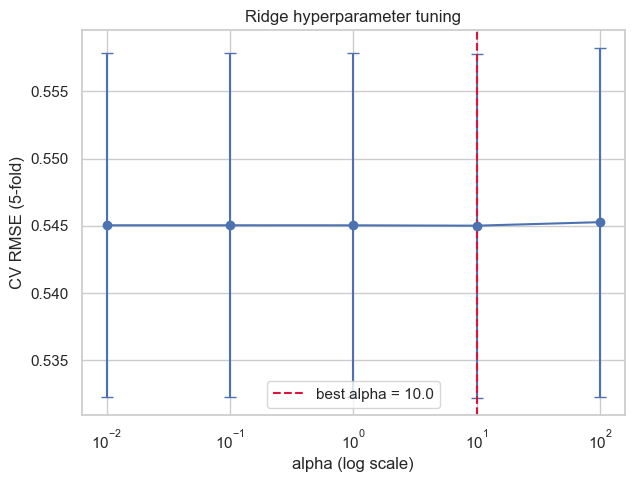

In [6]:
cv_df = pd.DataFrame(ridge_search.cv_results_)
alphas = cv_df['param_alpha'].astype(float).values
mean_rmse = -cv_df['mean_test_score'].values
std_rmse = cv_df['std_test_score'].values

fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(alphas, mean_rmse, yerr=std_rmse, marker='o', capsize=4, color='#4c72b0')
ax.axvline(ridge_search.best_params_['alpha'], color='crimson', linestyle='--',
           label=f'best alpha = {ridge_search.best_params_["alpha"]}')
ax.set_xscale('log')
ax.set_xlabel('alpha (log scale)')
ax.set_ylabel('CV RMSE (5-fold)')
ax.set_title('Ridge hyperparameter tuning')
ax.legend()
savefig('07_ridge_cv.png')
plt.show()

saved C:\My Random Things\Claude\MLFinals\figures\08_ridge_pred_vs_actual.png


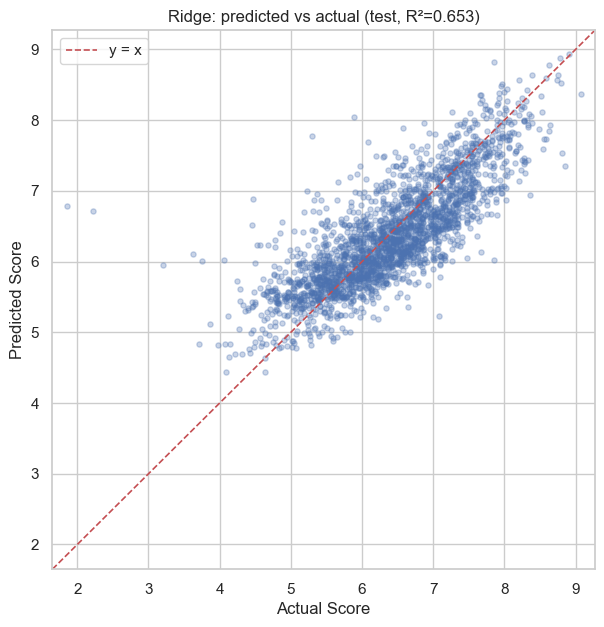

In [7]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, y_pred_ridge, alpha=0.3, s=14, color='#4c72b0')
lim = [min(y_test.min(), y_pred_ridge.min()) - 0.2,
       max(y_test.max(), y_pred_ridge.max()) + 0.2]
ax.plot(lim, lim, 'r--', linewidth=1.2, label='y = x')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Actual Score'); ax.set_ylabel('Predicted Score')
ax.set_title(f'Ridge: predicted vs actual (test, R\u00b2={ridge_metrics["R2"]:.3f})')
ax.legend()
savefig('08_ridge_pred_vs_actual.png')
plt.show()

In [8]:
# Coefficients are on standardized features, so magnitudes are comparable
# across columns. Sort by absolute value to see what the model leans on most,
# then re-print with the original signs for interpretation.
coefs = pd.Series(ridge_best.coef_, index=feature_names)
top10_signed = coefs.reindex(coefs.abs().sort_values(ascending=False).head(10).index)
print('Top 10 Ridge coefficients by |value| (signed, on standardized features):')
print(top10_signed.round(4).to_string())
results['Ridge']['top10_coefficients'] = top10_signed.to_dict()

Top 10 Ridge coefficients by |value| (signed, on standardized features):
log_Favorites        0.6103
Duration_min         0.1171
genre_Hentai        -0.1046
start_year           0.0967
Type_Music           0.0910
genre_Avant Garde   -0.0908
Source_Original     -0.0873
Type_TV             -0.0639
Studios_Sunrise      0.0634
Source_Music        -0.0611


## Random Forest Regressor

Captures non-linear interactions Ridge cannot reach. We use `RandomizedSearchCV` with 20 candidates over a small grid because a full sweep would take too long: trees scale roughly linearly with `n_estimators`, and `max_depth=None` builds very large trees on 11K rows. Random search hits a representative slice of the space in a fraction of the time. CV-averaged RMSE on the training folds drives the selection.

In [9]:
# Random Forest hyperparameters to tune. The full grid is 3 x 4 x 3 = 36
# combinations; with 5-fold CV that would be 180 fits. RandomizedSearchCV
# samples 20 of those 36 combos which is enough to find a good neighborhood.
rf_param_dist = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 5, 10],
}

# Note: each tree fit already parallelizes over cores via n_jobs=-1, so we
# leave the outer search at n_jobs=1. Nesting both leads to oversubscription
# and slower wall time on most machines.
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RNG, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=1,
    random_state=RNG,
    return_train_score=True,
    verbose=1,
)
t0 = time.time()
rf_search.fit(X_train, y_train)
print(f'RF RandomizedSearchCV done in {time.time()-t0:.1f}s')
print('Best params:', rf_search.best_params_)
print(f'Best CV RMSE: {-rf_search.best_score_:.4f}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits
RF RandomizedSearchCV done in 135.4s
Best params: {'n_estimators': 500, 'min_samples_leaf': 1, 'max_depth': 30}
Best CV RMSE: 0.4712


In [10]:
rf_best = rf_search.best_estimator_
y_pred_rf = rf_best.predict(X_test)
rf_metrics = report_metrics(y_test, y_pred_rf, 'Random Forest')
results['Random Forest'] = rf_metrics
results['Random Forest']['best_params'] = rf_search.best_params_

                 Random Forest  MAE=0.3265  RMSE=0.4567  R2=0.7475


saved C:\My Random Things\Claude\MLFinals\figures\09_rf_pred_vs_actual.png


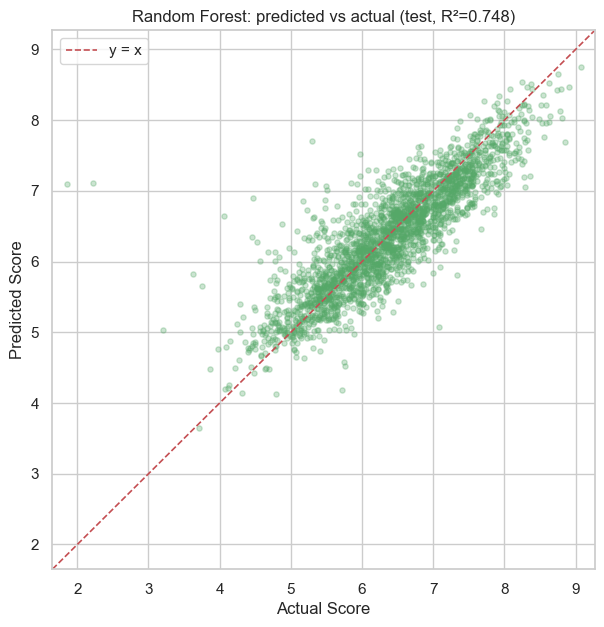

In [11]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, y_pred_rf, alpha=0.3, s=14, color='#55a868')
lim = [min(y_test.min(), y_pred_rf.min()) - 0.2,
       max(y_test.max(), y_pred_rf.max()) + 0.2]
ax.plot(lim, lim, 'r--', linewidth=1.2, label='y = x')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Actual Score'); ax.set_ylabel('Predicted Score')
ax.set_title(f'Random Forest: predicted vs actual (test, R\u00b2={rf_metrics["R2"]:.3f})')
ax.legend()
savefig('09_rf_pred_vs_actual.png')
plt.show()

saved C:\My Random Things\Claude\MLFinals\figures\10_rf_residuals.png


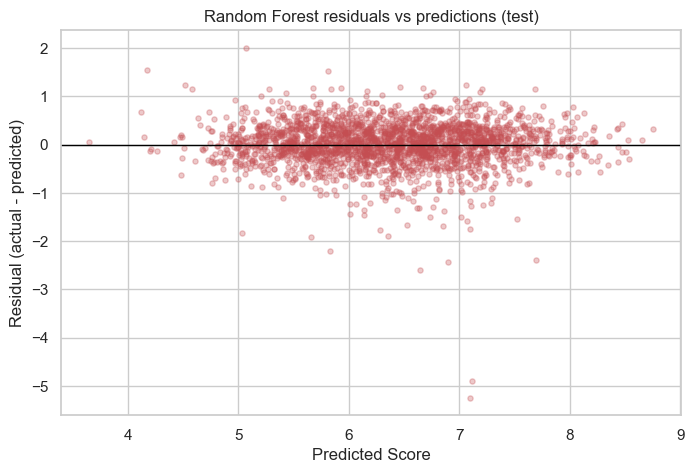

Residual mean=0.0128  std=0.4565


In [12]:
resid = y_test - y_pred_rf
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_pred_rf, resid, alpha=0.3, s=14, color='#c44e52')
ax.axhline(0, color='black', linewidth=1)
ax.set_xlabel('Predicted Score')
ax.set_ylabel('Residual (actual - predicted)')
ax.set_title('Random Forest residuals vs predictions (test)')
savefig('10_rf_residuals.png')
plt.show()
print(f'Residual mean={resid.mean():.4f}  std={resid.std():.4f}')

saved C:\My Random Things\Claude\MLFinals\figures\11_rf_feature_importance.png


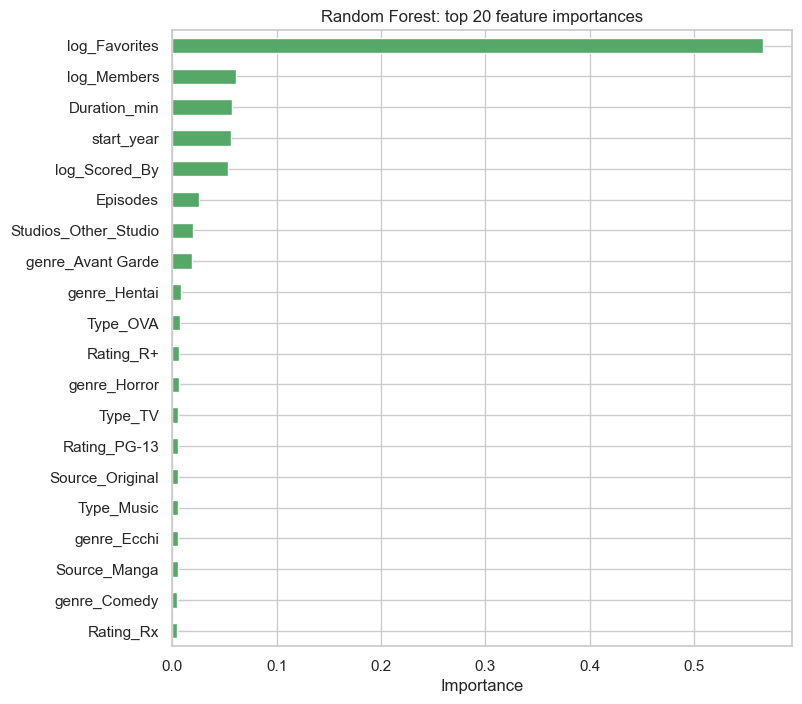

Top 15 features:
log_Favorites           0.5657
log_Members             0.0609
Duration_min            0.0576
start_year              0.0563
log_Scored_By           0.0533
Episodes                0.0253
Studios_Other_Studio    0.0195
genre_Avant Garde       0.0190
genre_Hentai            0.0087
Type_OVA                0.0070
Rating_R+               0.0065
genre_Horror            0.0060
Type_TV                 0.0059
Rating_PG-13            0.0057
Source_Original         0.0055


In [13]:
importances = pd.Series(rf_best.feature_importances_, index=feature_names).sort_values(ascending=False)
top20 = importances.head(20)
fig, ax = plt.subplots(figsize=(8, 8))
top20[::-1].plot.barh(ax=ax, color='#55a868')
ax.set_title('Random Forest: top 20 feature importances')
ax.set_xlabel('Importance')
savefig('11_rf_feature_importance.png')
plt.show()
print('Top 15 features:')
print(importances.head(15).round(4).to_string())
results['Random Forest']['top15_importances'] = importances.head(15).to_dict()

saved C:\My Random Things\Claude\MLFinals\figures\12_rf_tuning_heatmap.png


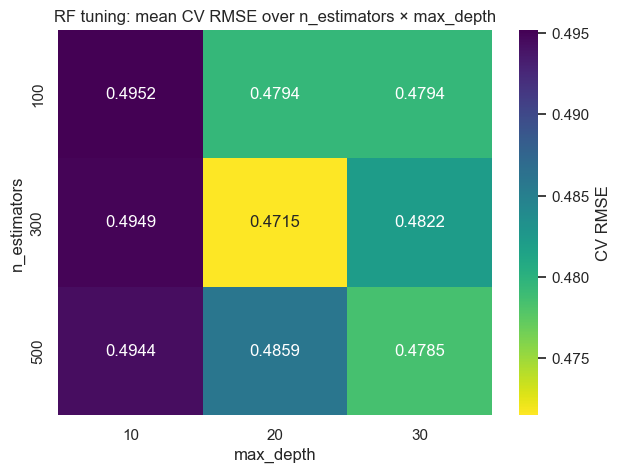

In [14]:
cv_rf = pd.DataFrame(rf_search.cv_results_).copy()
cv_rf['rmse'] = -cv_rf['mean_test_score']
cv_rf['max_depth_str'] = cv_rf['param_max_depth'].astype(str)
pivot = cv_rf.groupby(['param_n_estimators', 'max_depth_str'])['rmse'].mean().unstack()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='viridis_r', ax=ax,
            cbar_kws={'label': 'CV RMSE'})
ax.set_title('RF tuning: mean CV RMSE over n_estimators \u00d7 max_depth')
ax.set_xlabel('max_depth')
ax.set_ylabel('n_estimators')
savefig('12_rf_tuning_heatmap.png')
plt.show()

## Leakage ablation: drop the engagement features

log_Members, log_Favorites, and log_Scored_By are partially deterministic functions of Score because the MAL Score formula is a Bayesian-weighted average that down-weights low-vote anime. We retrain the best Random Forest on the same data with those three features removed to see how much of the predictive signal lives in metadata alone (genres, type, source, year, duration, studio) versus engagement counters.

In [15]:
# Re-run the pipeline with the three engagement features held out.
# split_and_scale supports drop_features so we don't have to re-implement
# the splitter. Same random_state so we're scoring on the same test rows.
leak_features = ['log_Members', 'log_Favorites', 'log_Scored_By']
splits_no_leak = split_and_scale(feats, drop_features=leak_features)
X_train_nl = splits_no_leak['X_train']
X_test_nl = splits_no_leak['X_test']
y_train_nl = splits_no_leak['y_train']
y_test_nl = splits_no_leak['y_test']
feature_names_nl = splits_no_leak['feature_names']
print(f'No-leak X_train shape: {X_train_nl.shape}  (down from {X_train.shape})')

# Train a fresh RF with the best hyperparameters from the full-feature search.
# We are not retuning here because the goal is to isolate the effect of the
# missing features, not to find the best model on the smaller feature set.
rf_nl = RandomForestRegressor(random_state=RNG, n_jobs=-1, **rf_search.best_params_)
t0 = time.time()
rf_nl.fit(X_train_nl, y_train_nl)
print(f'No-leak RF fit in {time.time()-t0:.1f}s')
y_pred_nl = rf_nl.predict(X_test_nl)
nl_metrics = report_metrics(y_test_nl, y_pred_nl, 'RF (no leakage features)')
results['RF no-leak'] = nl_metrics

No-leak X_train shape: (10990, 72)  (down from (10990, 75))
No-leak RF fit in 2.6s
      RF (no leakage features)  MAE=0.4336  RMSE=0.5782  R2=0.5954


saved C:\My Random Things\Claude\MLFinals\figures\13_leakage_ablation.png


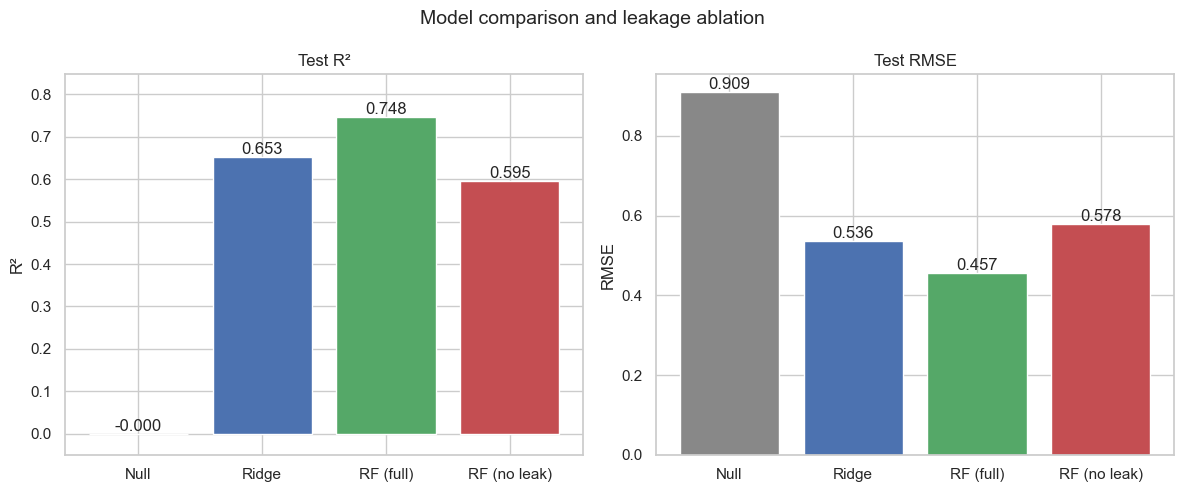

In [16]:
names = ['Null', 'Ridge', 'RF (full)', 'RF (no leak)']
r2_vals = [results['Null baseline']['R2'], results['Ridge']['R2'],
           results['Random Forest']['R2'], results['RF no-leak']['R2']]
rmse_vals = [results['Null baseline']['RMSE'], results['Ridge']['RMSE'],
             results['Random Forest']['RMSE'], results['RF no-leak']['RMSE']]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#888888', '#4c72b0', '#55a868', '#c44e52']
axes[0].bar(names, r2_vals, color=colors)
axes[0].set_title('Test R\u00b2'); axes[0].set_ylabel('R\u00b2')
axes[0].set_ylim(min(0, min(r2_vals)) - 0.05, max(r2_vals) + 0.1)
for i, v in enumerate(r2_vals):
    axes[0].text(i, v, f'{v:.3f}', ha='center', va='bottom')
axes[1].bar(names, rmse_vals, color=colors)
axes[1].set_title('Test RMSE'); axes[1].set_ylabel('RMSE')
for i, v in enumerate(rmse_vals):
    axes[1].text(i, v, f'{v:.3f}', ha='center', va='bottom')
fig.suptitle('Model comparison and leakage ablation', fontsize=14)
plt.tight_layout()
savefig('13_leakage_ablation.png')
plt.show()

## Feed-Forward Neural Network (TensorFlow/Keras)

Optional third model. Architecture: `Dense(128, relu) → Dropout(0.3) → Dense(64, relu) → Dropout(0.3) → Dense(1)`. Adam optimizer at lr=1e-3, MSE loss, EarlyStopping with patience 10 on val_loss, batch size 64, max 100 epochs. Operates on the same scaled feature matrix as Ridge and Random Forest, so the comparison is apples-to-apples. Neural networks rarely dominate on small tabular data; the question is whether dense layers can extract any non-linear interactions Random Forest is already exploiting.

In [17]:
import os
# Quiet the noisy oneDNN startup messages.
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf
from tensorflow.keras import layers, callbacks, models

# Seed both TF's RNG and numpy's RNG so the FFN's weight init and any sampling
# inside Keras are reproducible.
tf.random.set_seed(RNG)
np.random.seed(RNG)

# 128 -> dropout -> 64 -> dropout -> 1 is a standard tabular regression head.
# Dropout 0.3 is moderate; 0.5 would over-regularize on a 11K-row dataset.
ffn = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1),  # linear output for regression
])
ffn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='mse', metrics=['mae'])
ffn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         9,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,049 (70.50 KB)

 Trainable params: 18,049 (70.50 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# EarlyStopping watches the val loss; if it doesn't improve for 10 epochs we
# stop and roll back to the best weights. Saves us from training to the max
# epoch count when the model has already plateaued.
early = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
t0 = time.time()
history = ffn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[early],
    verbose=0,
)
print(f'FFN trained in {time.time()-t0:.1f}s, stopped at epoch {len(history.history["loss"])}')

FFN trained in 28.2s, stopped at epoch 100


In [19]:
y_pred_ffn = ffn.predict(X_test, verbose=0).ravel()
ffn_metrics = report_metrics(y_test, y_pred_ffn, 'FFN (128-64, dropout 0.3)')
results['FFN'] = ffn_metrics
results['FFN']['best_params'] = {'arch': '128-64', 'dropout': 0.3, 'epochs_run': len(history.history['loss'])}

     FFN (128-64, dropout 0.3)  MAE=0.3328  RMSE=0.4593  R2=0.7447


saved C:\My Random Things\Claude\MLFinals\figures\14_ffn_loss.png


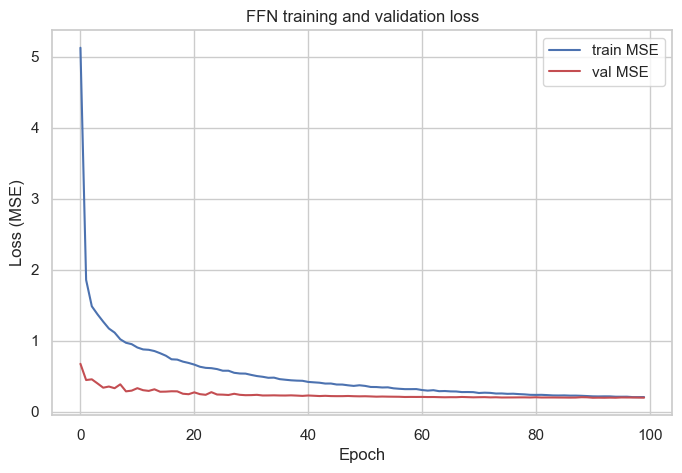

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history.history['loss'], label='train MSE', color='#4c72b0')
ax.plot(history.history['val_loss'], label='val MSE', color='#c44e52')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE)')
ax.set_title('FFN training and validation loss')
ax.legend()
savefig('14_ffn_loss.png')
plt.show()

saved C:\My Random Things\Claude\MLFinals\figures\15_ffn_pred_vs_actual.png


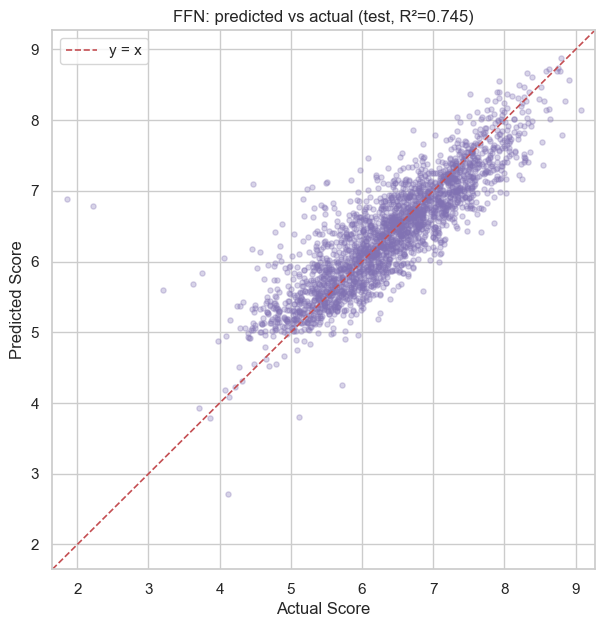

In [21]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, y_pred_ffn, alpha=0.3, s=14, color='#8172b3')
lim = [min(y_test.min(), y_pred_ffn.min()) - 0.2,
       max(y_test.max(), y_pred_ffn.max()) + 0.2]
ax.plot(lim, lim, 'r--', linewidth=1.2, label='y = x')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Actual Score'); ax.set_ylabel('Predicted Score')
ax.set_title(f'FFN: predicted vs actual (test, R²={ffn_metrics["R2"]:.3f})')
ax.legend()
savefig('15_ffn_pred_vs_actual.png')
plt.show()

## Final results table

In [22]:
rows = []
for name, m in results.items():
    rows.append({
        'Model': name,
        'MAE': round(m['MAE'], 4),
        'RMSE': round(m['RMSE'], 4),
        'R2': round(m['R2'], 4),
        'best_params': m.get('best_params', ''),
    })
summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

        Model    MAE   RMSE      R2                                                   best_params
Null baseline 0.7336 0.9089 -0.0000                                                              
        Ridge 0.4055 0.5356  0.6528                                               {'alpha': 10.0}
Random Forest 0.3265 0.4567  0.7475 {'n_estimators': 500, 'min_samples_leaf': 1, 'max_depth': 30}
   RF no-leak 0.4336 0.5782  0.5954                                                              
          FFN 0.3328 0.4593  0.7447         {'arch': '128-64', 'dropout': 0.3, 'epochs_run': 100}


## Persist trained artifacts

Save the trained sklearn models, both StandardScalers (full vs leak-free have different feature counts so they need different scalers), the MultiLabelBinarizer fitted on genres, the top-studios list, the column ordering for each model, the imputation medians, and a JSON dump of the test metrics. These get loaded by `src/predict.py` and the Streamlit app.

In [ ]:
import json
import joblib

MODELS_DIR = ROOT / 'models'
MODELS_DIR.mkdir(exist_ok=True)

# Sklearn models go through joblib; it handles numpy arrays inside the trees
# and scaler far more efficiently than pickle alone. compress=3 brings the
# RF pickles from ~480 MB down to ~95 MB each (still big, but manageable).
joblib.dump(rf_best, MODELS_DIR / 'rf_best.pkl', compress=3)
joblib.dump(rf_nl, MODELS_DIR / 'rf_no_leak.pkl', compress=3)
joblib.dump(ridge_best, MODELS_DIR / 'ridge_best.pkl')

# Two scalers: the full-feature scaler from the main split, and a separate
# scaler from the leak-free split (different feature counts, can't share).
joblib.dump(splits['scaler'], MODELS_DIR / 'scaler.pkl')
joblib.dump(splits_no_leak['scaler'], MODELS_DIR / 'scaler_no_leak.pkl')

# The MLB and top_studios are reused at inference to align the feature schema.
joblib.dump(mlb, MODELS_DIR / 'genre_binarizer.pkl')

# JSON for things that are just lists or simple dicts; easier to inspect.
with open(MODELS_DIR / 'feature_columns.json', 'w', encoding='utf-8') as f:
    json.dump(feature_names, f, indent=2)
with open(MODELS_DIR / 'feature_columns_no_leak.json', 'w', encoding='utf-8') as f:
    json.dump(splits_no_leak['feature_names'], f, indent=2)
with open(MODELS_DIR / 'top_studios.json', 'w', encoding='utf-8') as f:
    json.dump(list(top_studios), f, indent=2)
with open(MODELS_DIR / 'medians.json', 'w', encoding='utf-8') as f:
    json.dump(medians, f, indent=2)

# Test metrics for the sidebar in the UI. Drop nested dict-only fields so the
# JSON stays small and the UI can render it directly.
metrics_for_ui = {
    'rf_full': {k: float(results['Random Forest'][k]) for k in ('MAE', 'RMSE', 'R2')},
    'rf_no_leak': {k: float(results['RF no-leak'][k]) for k in ('MAE', 'RMSE', 'R2')},
    'ridge': {k: float(results['Ridge'][k]) for k in ('MAE', 'RMSE', 'R2')},
}
# Top-15 RF importances for the explainability expander.
metrics_for_ui['rf_full']['top_importances'] = [
    {'feature': k, 'importance': float(v)}
    for k, v in list(results['Random Forest']['top15_importances'].items())[:5]
]
with open(MODELS_DIR / 'test_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_for_ui, f, indent=2)

# Report total bytes so we can decide whether to gitignore the folder.
total_bytes = sum(p.stat().st_size for p in MODELS_DIR.iterdir() if p.is_file())
print(f'wrote {len(list(MODELS_DIR.iterdir()))} artifacts to {MODELS_DIR}')
print(f'total size: {total_bytes / 1024 / 1024:.1f} MB')

In [24]:
# Smoke test: load every artifact back and confirm shapes / counts. If this
# cell prints clean lines for everything, the Streamlit app should work.
import joblib, json
M = ROOT / 'models'
print('rf_best:       ', type(joblib.load(M / 'rf_best.pkl')).__name__)
print('rf_no_leak:    ', type(joblib.load(M / 'rf_no_leak.pkl')).__name__)
print('ridge_best:    ', type(joblib.load(M / 'ridge_best.pkl')).__name__)
print('scaler:        ', type(joblib.load(M / 'scaler.pkl')).__name__)
print('scaler_no_leak:', type(joblib.load(M / 'scaler_no_leak.pkl')).__name__)
print('mlb classes:   ', len(joblib.load(M / 'genre_binarizer.pkl').classes_))
print('feature cols:  ', len(json.load(open(M / 'feature_columns.json'))))
print('no-leak cols:  ', len(json.load(open(M / 'feature_columns_no_leak.json'))))
print('top studios:   ', len(json.load(open(M / 'top_studios.json'))))
print('medians keys:  ', sorted(json.load(open(M / 'medians.json')).keys()))
print('metrics:       ', list(json.load(open(M / 'test_metrics.json')).keys()))

rf_best:        RandomForestRegressor
rf_no_leak:     RandomForestRegressor
ridge_best:     Ridge
scaler:         StandardScaler
scaler_no_leak: StandardScaler
mlb classes:    21
feature cols:   75
no-leak cols:   72
top studios:    20
medians keys:   ['Duration_min', 'Episodes', 'log_Favorites', 'log_Members', 'log_Scored_By', 'start_year']
metrics:        ['rf_full', 'rf_no_leak', 'ridge']
